# Traffic Density Dataset Analysis

Notebook này khám phá bộ dữ liệu ảnh giao thông trước khi làm sạch và huấn luyện mô hình. Dữ liệu gốc chỉ được đọc, không bị sửa hoặc xóa.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

pd.set_option("display.max_columns", None)

## 1. Đường dẫn và cấu trúc dữ liệu

In [6]:
project_dir = Path.cwd()
if not (project_dir / "Final Dataset").exists():
    project_dir = project_dir.parent

data_dir = project_dir / "Final Dataset"
splits = ["training", "validation", "testing"]
class_names = ["Empty", "Low", "Medium", "High", "Traffic Jam"]
image_extensions = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

if not data_dir.exists():
    raise FileNotFoundError(f"Không tìm thấy dữ liệu tại: {data_dir}")

print(f"Dataset: {data_dir}")

Dataset: e:\Documents\DSEB.NEU.7TH\DEEP LEARNING\dl-traffic-density-classi\Final Dataset


In [7]:
folder_check = []
for split in splits:
    for class_name in class_names:
        folder = data_dir / split / class_name
        folder_check.append({
            "split": split,
            "class_name": class_name,
            "exists": folder.exists(),
        })

folder_check_df = pd.DataFrame(folder_check)
folder_check_df

,split,class_name,exists
0,training,Empty,True
1,training,Low,True
2,training,Medium,True
3,training,High,True
4,training,Traffic Jam,True
5,validation,Empty,True
6,validation,Low,True
7,validation,Medium,True
8,validation,High,True
9,validation,Traffic Jam,True


## 2. Quét và kiểm tra ảnh

Mỗi ảnh được mở bằng Pillow để lấy kích thước, định dạng và chế độ màu. Những file rỗng hoặc không đọc được được lưu riêng để kiểm tra.

In [8]:
records = []
errors = []

for split in splits:
    for class_name in class_names:
        class_dir = data_dir / split / class_name
        if not class_dir.exists():
            continue

        for image_path in sorted(class_dir.iterdir()):
            if not image_path.is_file() or image_path.suffix.lower() not in image_extensions:
                continue

            relative_path = image_path.relative_to(project_dir).as_posix()
            file_size = image_path.stat().st_size

            if file_size == 0:
                errors.append({
                    "path": relative_path,
                    "split": split,
                    "class_name": class_name,
                    "error": "Empty file",
                })
                continue

            try:
                with Image.open(image_path) as image:
                    image.load()
                    width, height = image.size
                    records.append({
                        "path": relative_path,
                        "split": split,
                        "class_name": class_name,
                        "extension": image_path.suffix.lower(),
                        "format": image.format,
                        "mode": image.mode,
                        "width": width,
                        "height": height,
                        "aspect_ratio": width / height,
                        "file_size_kb": file_size / 1024,
                    })
            except Exception as error:
                errors.append({
                    "path": relative_path,
                    "split": split,
                    "class_name": class_name,
                    "error": str(error),
                })

images_df = pd.DataFrame(records)
errors_df = pd.DataFrame(errors)

print(f"Số ảnh đọc được: {len(images_df):,}")
print(f"Số ảnh lỗi hoặc rỗng: {len(errors_df):,}")

Số ảnh đọc được: 4,038
Số ảnh lỗi hoặc rỗng: 0


In [9]:
images_df.head()

,path,split,class_name,extension,format,mode,width,height,aspect_ratio,file_size_kb
0,Final Dataset/training/Empty/00578c39-338c-457...,training,Empty,.jpg,JPEG,RGB,640,360,1.777778,28.070312
1,Final Dataset/training/Empty/005c5c56-aca7-4f3...,training,Empty,.jpg,JPEG,RGB,320,240,1.333333,11.919922
2,Final Dataset/training/Empty/009b6491-894f-400...,training,Empty,.jpg,JPEG,RGB,640,480,1.333333,43.206055
3,Final Dataset/training/Empty/01027fbc-f458-4f2...,training,Empty,.jpg,JPEG,RGB,640,480,1.333333,57.157227
4,Final Dataset/training/Empty/013561a0-ab9a-4e0...,training,Empty,.jpg,JPEG,RGB,320,240,1.333333,13.062500


In [10]:
if errors_df.empty:
    print("Không phát hiện ảnh lỗi hoặc file rỗng.")
else:
    display(errors_df)

Không phát hiện ảnh lỗi hoặc file rỗng.


## 3. Số lượng ảnh theo split và lớp

In [11]:
split_counts = images_df["split"].value_counts().reindex(splits)
split_counts.rename("number_of_images").to_frame()

,number_of_images
split,
training,3378
validation,340
testing,320


In [12]:
class_by_split = pd.crosstab(images_df["split"], images_df["class_name"])
class_by_split = class_by_split.reindex(index=splits, columns=class_names, fill_value=0)
class_by_split["Total"] = class_by_split.sum(axis=1)
class_by_split

class_name,Empty,Low,Medium,High,Traffic Jam,Total
split,,,,,,
training,1186,936,688,378,190,3378
validation,120,94,70,38,18,340
testing,64,64,64,64,64,320


In [13]:
class_summary = images_df["class_name"].value_counts().reindex(class_names).rename("count").to_frame()
class_summary["percentage"] = (class_summary["count"] / class_summary["count"].sum() * 100).round(2)
class_summary

,count,percentage
class_name,,
Empty,1370,33.93
Low,1094,27.09
Medium,822,20.36
High,480,11.89
Traffic Jam,272,6.74


In [14]:
largest_class = class_summary["count"].max()
smallest_class = class_summary["count"].min()
imbalance_ratio = largest_class / smallest_class
print(f"Tỷ lệ lớp lớn nhất / lớp nhỏ nhất: {imbalance_ratio:.2f}")

Tỷ lệ lớp lớn nhất / lớp nhỏ nhất: 5.04


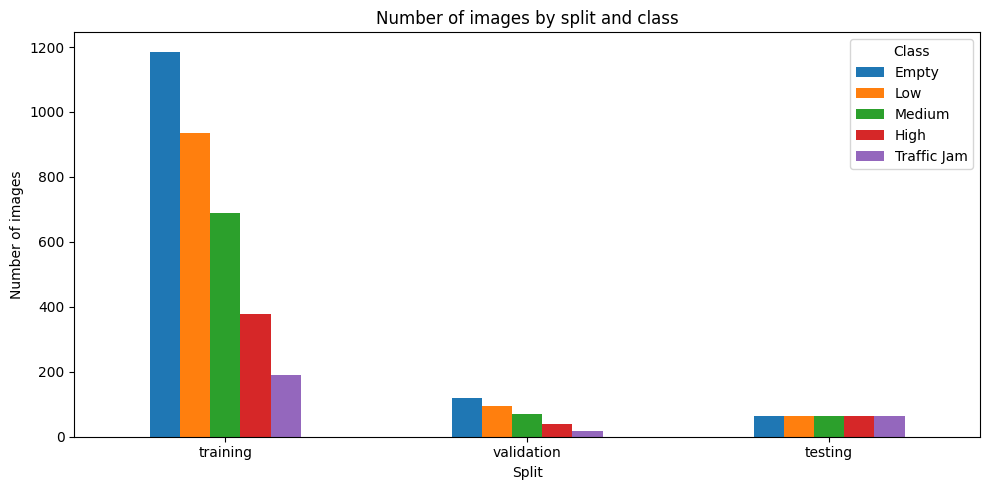

In [15]:
plot_data = class_by_split.drop(columns="Total")
plot_data.plot(kind="bar", figsize=(10, 5))
plt.title("Number of images by split and class")
plt.xlabel("Split")
plt.ylabel("Number of images")
plt.xticks(rotation=0)
plt.legend(title="Class")
plt.tight_layout()
plt.show()

## 4. Định dạng và chế độ màu

In [16]:
format_summary = pd.DataFrame({
    "extension": images_df["extension"].value_counts(),
    "decoded_format": images_df["format"].value_counts(),
}).fillna(0).astype(int)
format_summary

,extension,decoded_format
.jpeg,11,0
.jpg,4027,0
JPEG,0,4033
PNG,0,1
WEBP,0,4


In [17]:
images_df["mode"].value_counts().rename("count").to_frame()

,count
mode,
RGB,4037
RGBA,1


## 5. Kích thước và tỷ lệ ảnh

In [18]:
images_df[["width", "height", "aspect_ratio", "file_size_kb"]].describe().round(2)

,width,height,aspect_ratio,file_size_kb
count,4038.00,4038.00,4038.00,4038.00
mean,611.53,403.13,1.54,57.08
std,132.49,98.93,0.22,54.22
min,111.00,119.00,0.71,8.24
25%,640.00,360.00,1.33,32.25
50%,640.00,360.00,1.33,41.95
75%,640.00,480.00,1.78,78.45
max,4256.00,2832.00,2.98,1846.38


In [19]:
common_sizes = (
    images_df.groupby(["width", "height"])
    .size()
    .sort_values(ascending=False)
    .head(10)
    .rename("count")
    .reset_index()
)
common_sizes

,width,height,count
0,640,360,1796
1,640,480,1777
2,320,240,363
3,300,168,19
4,299,168,6
5,275,183,3
6,310,163,3
7,700,394,3
8,281,179,3
9,485,273,2


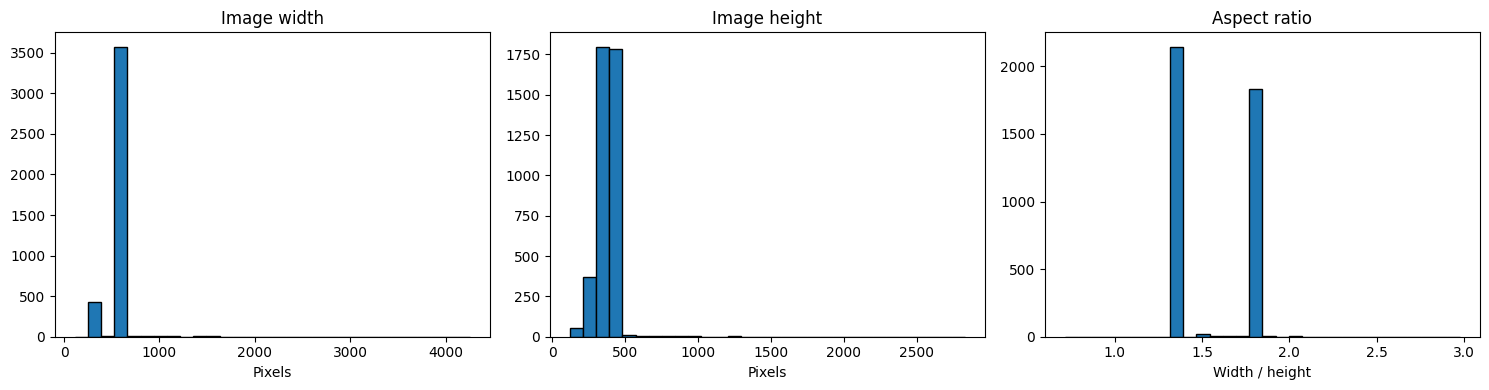

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(images_df["width"], bins=30, edgecolor="black")
axes[0].set_title("Image width")
axes[0].set_xlabel("Pixels")

axes[1].hist(images_df["height"], bins=30, edgecolor="black")
axes[1].set_title("Image height")
axes[1].set_xlabel("Pixels")

axes[2].hist(images_df["aspect_ratio"], bins=30, edgecolor="black")
axes[2].set_title("Aspect ratio")
axes[2].set_xlabel("Width / height")

plt.tight_layout()
plt.show()

## 6. Ảnh mẫu theo từng lớp

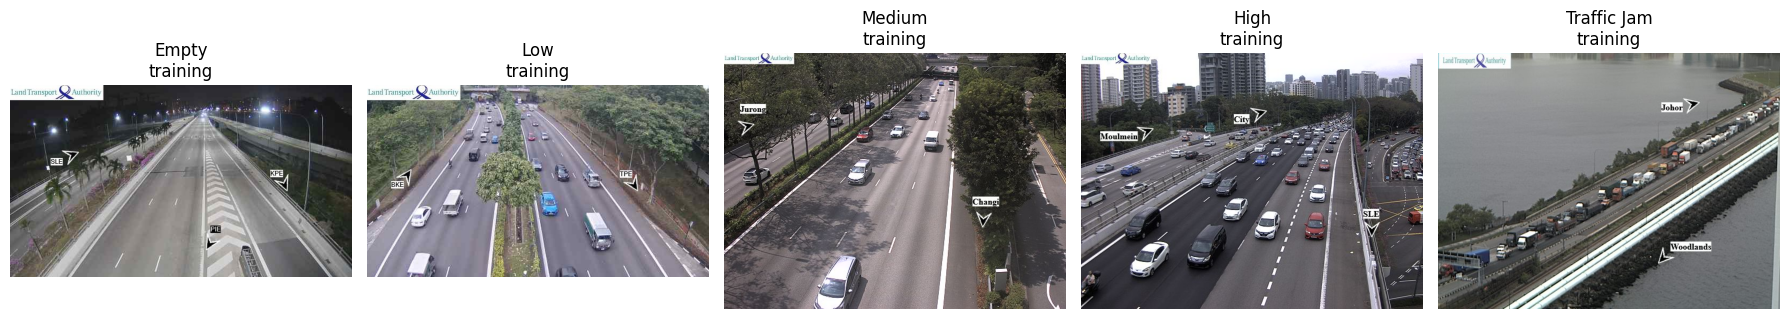

In [21]:
sample_rows = []
for class_name in class_names:
    class_images = images_df[images_df["class_name"] == class_name]
    sample_rows.append(class_images.sample(n=1, random_state=42).iloc[0])

fig, axes = plt.subplots(1, len(class_names), figsize=(18, 4))

for axis, row in zip(axes, sample_rows):
    image_path = project_dir / row["path"]
    with Image.open(image_path) as image:
        axis.imshow(image.convert("RGB"))
    axis.set_title(f"{row['class_name']}\n{row['split']}")
    axis.axis("off")

plt.tight_layout()
plt.show()

## 7. Tóm tắt ban đầu

Các kết quả trong notebook này mô tả dữ liệu gốc. Việc phát hiện duplicate, xử lý nhãn xung đột và tạo clean split sẽ được thực hiện riêng trong bước data cleaning.

In [22]:
print(f"Total valid images: {len(images_df):,}")
print(f"Unreadable or empty images: {len(errors_df):,}")
print(f"Number of classes: {images_df['class_name'].nunique()}")
print(f"Number of image sizes: {images_df[['width', 'height']].drop_duplicates().shape[0]}")
print(f"Class imbalance ratio: {imbalance_ratio:.2f}")

Total valid images: 4,038
Unreadable or empty images: 0
Number of classes: 5
Number of image sizes: 67
Class imbalance ratio: 5.04
